In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Измерение диаметра проволоки

In [2]:
diameter_data = pd.read_csv(
    "data/diameter.csv",
    sep=r"\s+",      # разделитель — пробелы/табы
    decimal=",",     # запятая как десятичный разделитель
    skiprows=[1],    # пропустить строку с единицами "мм мм"
    encoding="utf-8"
)

In [3]:
diameter_data

,d_мк,d_шт
0,0.37,0.30
1,0.37,0.30
2,0.37,0.30
3,0.36,0.30
4,0.37,0.30
5,0.37,0.30
6,0.37,0.25
7,0.37,0.25
8,0.36,0.30


In [4]:
for col in diameter_data.columns:
    x = diameter_data[col].to_numpy()          # переводим столбец в numpy-массив
    n = x.size
    mean = np.mean(x)               # среднее
    std = np.std(x, ddof=1)         # выборочное СКО
    sem = std / np.sqrt(n)          # погрешность среднего (SEM)

    print(f"{col}: mean = {mean:.4f}, std = {std:.4f}, SEM = {sem:.4f}")

d_мк: mean = 0.3678, std = 0.0044, SEM = 0.0015
d_шт: mean = 0.2889, std = 0.0220, SEM = 0.0073


# Снятие вольт-амперной характеристики

In [5]:
dU = 5 # мВ - цена деления
U_err = 5 # мВ
I_err = 0.1 # мА

In [6]:
len20cm_data = pd.read_csv(
    "data/len20cm.csv",
    sep=r"\s+",      # разделитель — пробелы/табы
    decimal=",",     # запятая как десятичный разделитель
    skiprows=[1],    # пропустить строку с единицами "мм мм"
    encoding="utf-8"
)
len20cm_data["U"] = len20cm_data["U_n"] * dU

In [7]:
len30cm_data = pd.read_csv(
    "data/len30cm.csv",
    sep=r"\s+",      # разделитель — пробелы/табы
    decimal=",",     # запятая как десятичный разделитель
    skiprows=[1],    # пропустить строку с единицами "мм мм"
    encoding="utf-8"
)
len30cm_data["U"] = len30cm_data["U_n"] * dU

In [8]:
len50cm_data = pd.read_csv(
    "data/len50cm.csv",
    sep=r"\s+",      # разделитель — пробелы/табы
    decimal=",",     # запятая как десятичный разделитель
    skiprows=[1],    # пропустить строку с единицами "мм мм"
    encoding="utf-8"
)
len50cm_data["U"] = len50cm_data["U_n"] * dU

# Построение графика

In [9]:
def least_squares(x, y): # y = kx
    coeff = np.mean(x*y) / np.mean(x*x)
    err = 1 / np.sqrt(len(x)) * np.sqrt((y*y).mean() / (x*x).mean() - coeff ** 2)
    return coeff, err # coeff = k

def least_squares_reversed(y, x): # y = kx
    coeff = np.mean(x*y) / np.mean(x*x)
    err = 1 / np.sqrt(len(x)) * np.sqrt((y*y).mean() / (x*x).mean() - coeff ** 2)
    return coeff, err # coeff = 1 / k

k20, err20 = least_squares(len20cm_data['U'], len20cm_data['I'])
k30, err30 = least_squares(len30cm_data['U'], len30cm_data['I'])
k50, err50 = least_squares(len50cm_data['U'], len50cm_data['I'])
# I = kU

R20, R_err20 = least_squares_reversed(len20cm_data['U'], len20cm_data['I'])
R30, R_err30 = least_squares_reversed(len30cm_data['U'], len30cm_data['I'])
R50, R_err50 = least_squares_reversed(len50cm_data['U'], len50cm_data['I'])

print(k20, err20)
print(k30, err30)
print(k50, err50)
print()
print(R20, R_err20)
print(R30, R_err30)
print(R50, R_err50)

0.5593377267919616 0.0018704395662514544
0.37570938144961885 0.0009879692782764145
0.22474512283748455 0.0003376038349964332

1.7875287910175146 0.005977541682570762
2.661355657770387 0.006998328384282849
4.449334166232802 0.006683625694462422


In [10]:
xline = np.linspace(0, 800, 10)
y20 = xline * k20
y30 = xline * k30
y50 = xline * k50

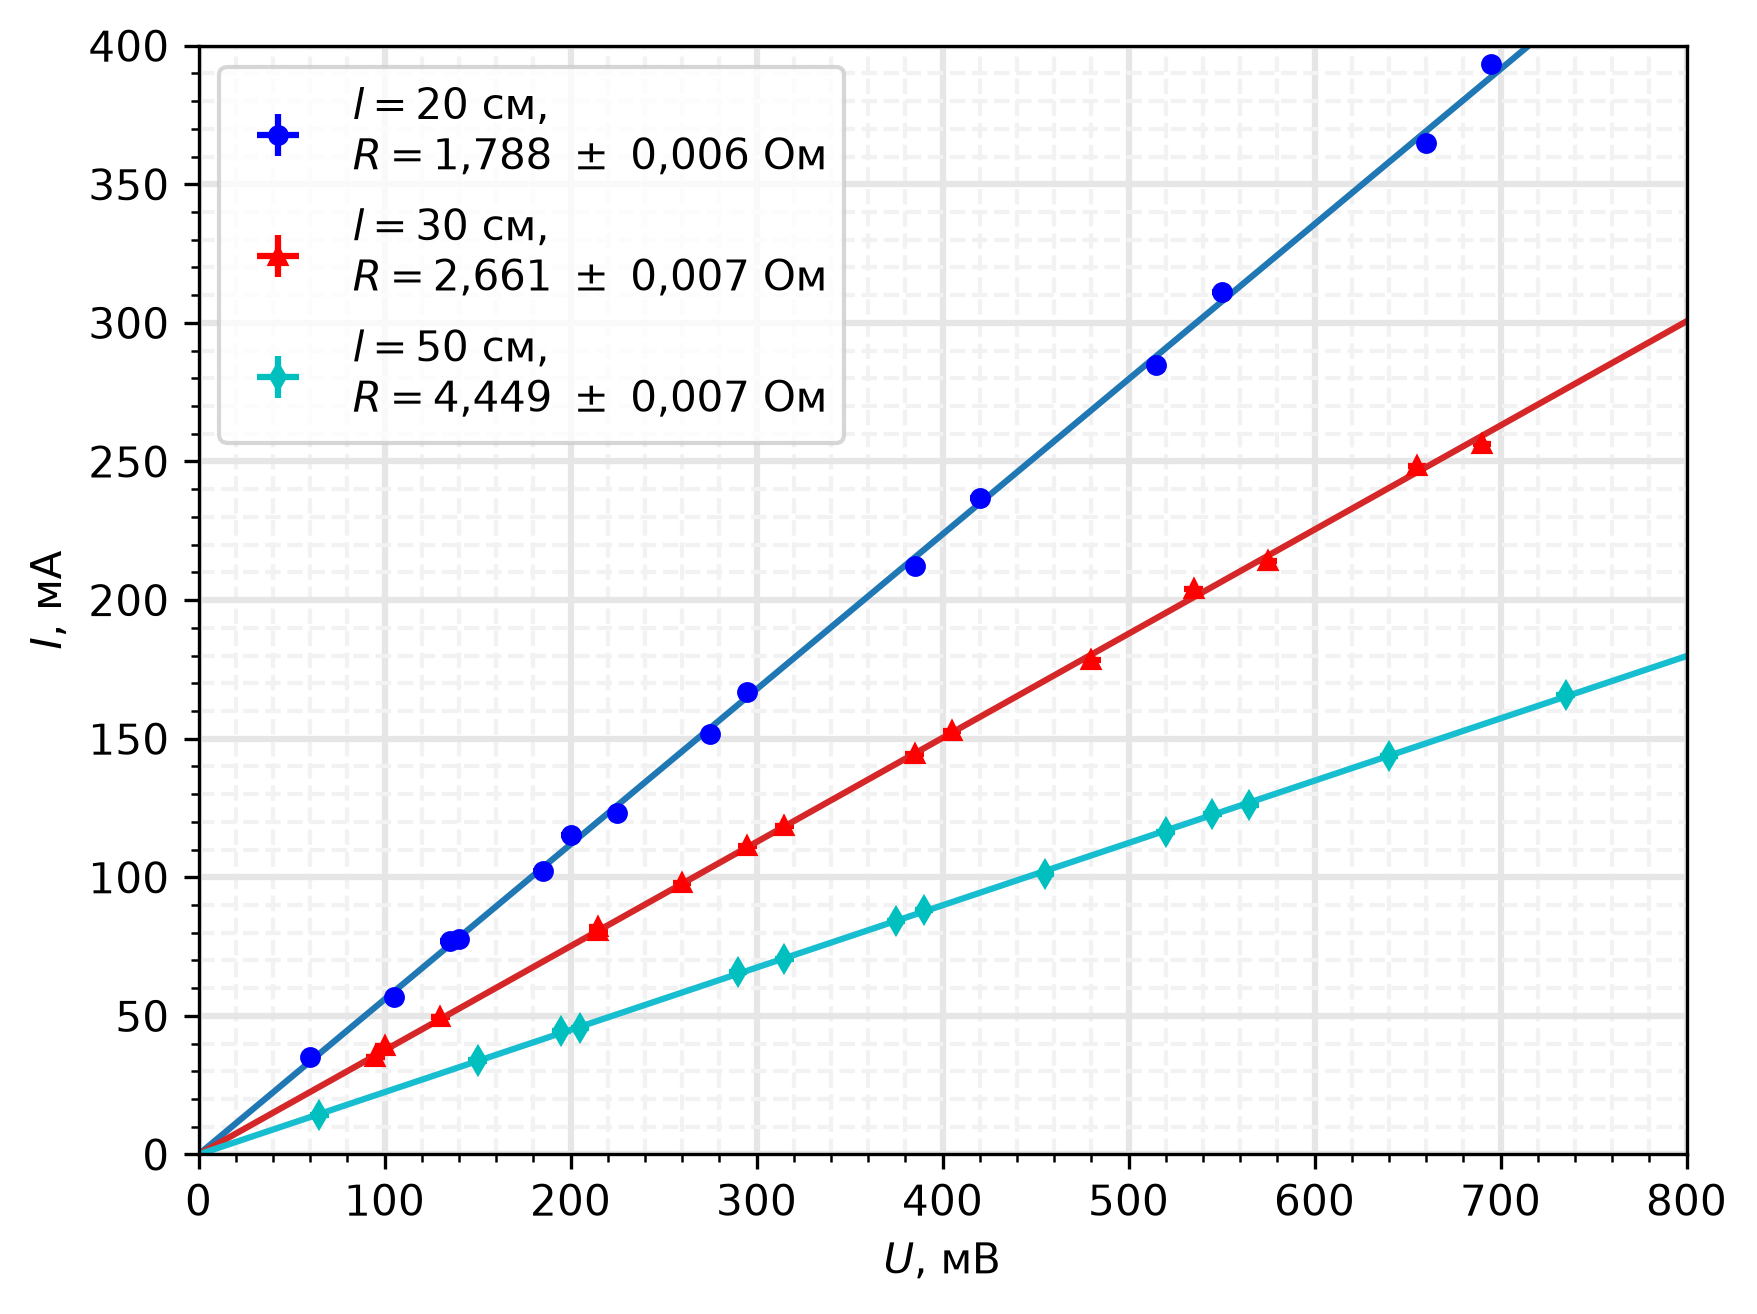

In [11]:
plt.figure(dpi=300)
plt.axis([0, 800, 0, 400])
plt.minorticks_on()
plt.ylabel("$I$, мА")
plt.xlabel("$U$, мВ")

plt.grid(visible=True, which='major', linestyle='-', linewidth=1.5, color='0.9') # Формат основных линиий сетки
plt.grid(visible=True, which='minor', linestyle='--', linewidth=1, color='0.95') # Формат побочных линий, цвет указывается как оттенок серого - 0.0 - чёрный, 1.0 - белый

plt.errorbar(len20cm_data["U"], len20cm_data["I"], xerr=U_err, yerr=I_err, fmt="bo", markersize=4, label="$l=20$ см,\n$R=1{,}788\\ \\pm\\ 0{,}006$ Ом")
plt.errorbar(len30cm_data["U"], len30cm_data["I"], xerr=U_err, yerr=I_err, fmt="r^", markersize=4, label="$l=30$ см,\n$R=2{,}661\\ \\pm\\ 0{,}007$ Ом")
plt.errorbar(len50cm_data["U"], len50cm_data["I"], xerr=U_err, yerr=I_err, fmt="cd", markersize=4, label="$l=50$ см,\n$R=4{,}449\\ \\pm\\ 0{,}007$ Ом")

plt.plot(xline, y20, color="tab:blue")
plt.plot(xline, y30, color="tab:red")
plt.plot(xline, y50, color="tab:cyan")

plt.legend()
plt.savefig("images/graph.pdf", format="pdf")